Uses the modified A-matrix/b-vector formulation, and compares with the regular MEEM formulation. Many plots to illustrate the behavior of both.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

import sys
from pathlib import Path

HERE = Path.cwd().resolve()
dir_path_str_1 = str((HERE / ".." ).resolve())
dir_path_str_2 = str((HERE / ".." / "..").resolve())
for dir_path_str in [dir_path_str_1, dir_path_str_2]:
  if dir_path_str not in sys.path:
    sys.path.insert(0, dir_path_str)

from helpers import *
from plotting_helpers import *
from modified_meem import SProblem
from capytaine_generator import CapytaineSlantSolver


import pickle

In [2]:
# Variable definitions: Matching most variables with the ps3 geometries.
file1 = str((HERE / "data" / "ps6.pkl").resolve())

h = 100
m0 = 0.9
rho = 1023
numerators = list(range(1, 8)) + list(range(8, 16, 2)) + list(range(16, 32, 4))
# configurations = []

# for num in numerators:
#   theta = np.pi * num / 64
#   d1 = (1/np.tan(theta) * 4) + 5
#   configurations.append({"name" : "config-t-" + str(num) +"pi-64",
#                         "h" : h,
#                         "a" : [3, 7],
#                         "theta" : theta,
#                         "d_in" : [d1, d1],
#                         "d_out" : [d1, 5], 
#                         "heaving" : [0, 1],
#                         "m0" : m0, 
#                         "rho" : rho})

with open(file1, "rb") as f:
  configurations = pickle.load(f)

In [3]:
# Solving MEEM/capytaine functions
def solve_prob(prob_style, config, res, version, nmk = 150):
  h, a, d_in, d_out, heaving, m0, rho = config["h"], config["a"], config["d_in"], config["d_out"], config["heaving"], config["m0"], config["rho"]
  return solve_problem(prob_style, h, a, d_in, d_out, heaving, m0, rho, res, version, nmk = nmk)

def solve_box_MEEM(config, nmk = 150):
   h, d, a, heaving, m0, rho = config["h"], config["d_out"], config["a"], config["heaving"], config["m0"], config["rho"]
   NMK = [nmk, nmk, nmk]
   prob = Problem(h, d, a, heaving, NMK, m0, rho)
   a_matrix = prob.a_matrix()
   b_vector = prob.b_vector()
   x = prob.get_unknown_coeffs(a_matrix, b_vector)
   am, dp = prob.hydro_coeffs(x, "capytaine")
   return am, dp

css = CapytaineSlantSolver(False, False, False, False, False)

def compute_cpt_slant(config):
  t_densities = [30, 60]
  f_densities = [15, 140, 15]
  respack = css.construct_and_solve(config["a"], config["d_in"], config["d_out"], config["heaving"], t_densities, 150, config["h"],
                                    None, config["rho"], f_densities = f_densities, m0 = config["m0"])
  am, dp = (respack[0].added_mass)["Heave"], (respack[0].radiation_damping)["Heave"]
  return am, dp

In [4]:
# More specific data generation functions
# for each configuration:
# 1. get the capytaine slant values
# 2. box-configuration convergence study
# 3. run MEEM-solver for regular MEEM and slant MEEM, convergence wrt different values

def get_capytaine_data(config, configurations):
  am, dp = compute_cpt_slant(config)
  config["CPT slant AM"] = am
  config["CPT slant DP"] = dp
  update_data_file(configurations, file1)
  print("Finished " + config["name"] + "CPT slant computations.")

def box_MEEM_convergence(config, configurations):
  nmks = range(10, 301, 10)
  ams = []
  dps = []
  for nmk in nmks:
    am, dp = solve_box_MEEM(config, nmk = nmk)
    ams.append(am)
    dps.append(dp)
  config["MEEM box AMs"], config["MEEM box DPs"] = ams, dps
  update_data_file(configurations, file1)
  print("Finished " + config["name"] + "MEEM box computations.")

def make_outline(config):
  a, d_in, d_out = config["a"], config["d_in"], config["d_out"]
  def outline_function(r):
    region = 0
    for rad in a:
      if r <= rad: break
      else: region += 1
    if region == len(a): return 0
    elif d_in[region] == d_out[region]:
      return - d_in[region]
    else:
      inner_rad = 0 if region == 0 else a[region - 1]
      outer_rad = a[region]
      slope = (d_in[region] - d_out[region])/(outer_rad - inner_rad)
      return slope * (r - inner_rad) - d_in[region]
  return outline_function

def vary_res(config, configurations, prob_style):
  nmk = 150
  resolutions = list(range(5, 51, 5))
  ams = []
  dps = []
  if prob_style == Problem:
    for res in resolutions:
      x, cs, prob = solve_problem(prob_style, config, res, 2, nmk = nmk)
      am, dp = prob.hydro_coeffs(x, "capytaine")
      ams.append(am)
      dps.append(dp)
    config["res MEEM regular AMs"], config["res MEEM regular DPs"] = ams, dps
  else:
    outline_function = make_outline(config)
    for res in resolutions:
      x, cs, prob = solve_problem(prob_style, config, res, 1, nmk = nmk)
      am_lst, dp_lst = [], []
      for frac1 in [entry / 20 for entry in range(1, 20)]:
        am, dp = prob.hydros_by_averages(cs, outline_function, "capytaine", frac1)
        am_lst.append(am)
        dp_lst.append(dp)
      ams.append(am_lst)
      dps.append(dp_lst)
    config["res MEEM modded AMs"], config["res MEEM modded DPs"] = ams, dps
  update_data_file(configurations, file1)
  print("Finished " + config["name"] + " res computations.")

def vary_nmk(config, configurations, prob_style):
  res = 30
  nmks = list(range(25, 251, 25))
  ams = []
  dps = []
  if prob_style == Problem:
    for nmk in nmks:
      x, cs, prob = solve_problem(prob_style, config, res, 2, nmk = nmk)
      am, dp = prob.hydro_coeffs(x, "capytaine")
      ams.append(am)
      dps.append(dp)
    config["nmk MEEM regular AMs"], config["nmk MEEM regular DPs"] = ams, dps
  else:
    outline_function = make_outline(config)
    for nmk in nmks:
      x, cs, prob = solve_problem(prob_style, config, res, 1, nmk = nmk)
      am_lst, dp_lst = [], []
      for frac1 in [entry / 20 for entry in range(1, 20)]:
        am, dp = prob.hydros_by_averages(cs, outline_function, "capytaine", frac1)
        am_lst.append(am)
        dp_lst.append(dp)
      ams.append(am_lst)
      dps.append(dp_lst)
    config["nmk MEEM modded AMs"], config["nmk MEEM modded DPs"] = ams, dps
  update_data_file(configurations, file1)
  print("Finished " + config["name"] + " nmk computations.")

In [5]:
# Generate data (commented out)
# for config in configurations:
#   # Solve Capytaine Slant
#   get_capytaine_data(config, configurations)
#   # Convergence study for box-MEEM
  # box_MEEM_convergence(config, configurations)
#   # Vary res for regular MEEM
#   vary_res(config, configurations, Problem)
#   # Vary res for modded MEEM
#   vary_res(config, configurations, SProblem)
#   # Vary nmk for regular MEEM
#   vary_nmk(config, configurations, Problem)
#   # Vary nmk for modded MEEM
#   vary_nmk(config, configurations, SProblem)

In [6]:
# Helper functions for data modification/plotting
def extract(configurations, key, length = None):
  if type(configurations[0][key]) != list:
     return [config[key] for config in configurations]
  if length is None:
     length = len(configurations[0][key])
  all_series = []
  for i in range(length):
    single_series = [config[key][i] for config in configurations]
    all_series.append(single_series)
  return all_series

def lists_shape(lst):
  output = ""
  while True:
      if type(lst) == list:
         output = output + str(len(lst)) + " "
         lst = lst[0]
      else:
         break
  print(output)

def transpose(matrix):
    return [list(row) for row in zip(*matrix)]

In [13]:
# Functions for various plots

def plot1(configurations, coeff, varied):
  cpt_values = extract(configurations, "CPT slant " + coeff)
  meem_reg_values = extract(configurations, varied + " MEEM regular " + coeff + "s")
  ys = list_ratios(meem_reg_values, cpt_values)
  if varied == "res":
    labs = make_label(list(range(5, 51, 5)), "res")
    const = "nmk = 150"
  elif varied == "nmk":
    labs = make_label(list(range(25, 251, 25)), "nmk")
    const = "res = 30"
  thetas = extract(configurations, "theta")
  plot_multiple_fade(thetas, ys, labs = labs,
                     title = "Regular MEEM formulation " + coeff +"s, varying " + varied + ", " + const, xlab = "theta", ylab = "Ratio of MEEM to CPT")
  
def plot2(configurations, coeff, varied, entry):
  cpt_values = extract(configurations, "CPT slant " + coeff)
  meem_mod_lst = extract(configurations, varied + " MEEM modded " + coeff + "s")
  meem_mod_values = [[lst[entry] for lst in lst_of_lsts] for lst_of_lsts in meem_mod_lst]
  ys = list_ratios(meem_mod_values, cpt_values)
  if varied == "res":
    labs = make_label(list(range(5, 51, 5)), "res")
    const = "nmk = 150"
  elif varied == "nmk":
    labs = make_label(list(range(25, 251, 25)), "nmk")
    const = "res = 30"
  thetas = extract(configurations, "theta")
  frac = f"{((entry + 1) * 0.05):.2f}"
  plot_multiple_fade(thetas, ys, labs = labs,
                     title = "Modded MEEM formulation " + coeff +"s, varying " + varied + ", " + const + " frac = " + frac, xlab = "theta", ylab = "Ratio of MEEM to CPT")
  
def plot3(configurations, coeff, varied, index):
  # Plot the highest res/NMK values, fade over the fractions
  cpt_values = extract(configurations, "CPT slant " + coeff)
  meem_mod_high_varied = (extract(configurations, varied + " MEEM modded " + coeff + "s"))[index]
  ys = list_ratios(transpose(meem_mod_high_varied), cpt_values)
  fracs = [f"{((entry + 1) * 0.05):.2f}" for entry in range(19)]
  thetas = extract(configurations, "theta")
  labs = make_label(fracs, "frac")
  plot_multiple_fade(thetas, ys, labs = labs, title = "Modded MEEM formulation " + coeff +"s, max " + varied, xlab = "theta", ylab = "Ratio of MEEM to CPT")

def plot4(configurations, coeff): # box convergence
  meem_values = extract(configurations, "MEEM box " + coeff + "s")
  base_values = meem_values[-1]
  ys = list_ratios(meem_values, base_values)[::4]
  thetas = extract(configurations, "theta")
  labs = make_label(list(range(10, 301, 10)), "nmk")[::4]
  plot_multiple_fade(thetas, ys, labs = labs, title = "MEEM box " + coeff +"s, convergence", xlab = "theta", ylab = "Ratio of MEEM value to best MEEM")

def plot5(configurations, coeff, style, index = 5):
  # plot each data point's ratio to true value on y, delta-d on x
  cmap = plt.get_cmap("plasma")
  color_vals = np.linspace(0.8, 0.2, len(configurations))
  for j in range(len(configurations)):
    config = configurations[j]
    cpt_val = config["CPT slant " + coeff]
    xs = []
    ys = []
    for i in range(10):
      res = ( i + 1 ) * 5
      x = (config["d_in"][0] - 5) / res
      if style == "regular":
        y = (config["res MEEM " + style + " " + coeff + "s"][i])/cpt_val
      elif style == "modded":
        y = (config["res MEEM " + style + " " + coeff + "s"][i][index])/cpt_val
      xs.append(x)
      ys.append(y)
    num = round(config["theta"] / pi * 64)
    lab = f"{num}π/{64}"
    plt.plot(xs, ys, label = lab, color=cmap(color_vals[j]))
  plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
  plt.xlabel("delta-d")
  plt.ylabel("ratio to Capytaine value")
  plt.title(coeff + " closeness dependence on delta-d (NMK = 150), " + style + " MEEM")
  plt.grid(True)
  plt.show()

def plot6(configurations, coeff, index = 9):
  # plot each data point's ratio to true value on y, delta-d on x
  cmap1 = plt.get_cmap("viridis")
  color_vals1 = np.linspace(0.8, 0.2, len(configurations))
  cmap2 = plt.get_cmap("magma")
  color_vals2 = np.linspace(0.8, 0.2, len(configurations))
  for j in range(len(configurations)):
    config = configurations[j]
    cpt_val = config["CPT slant " + coeff]
    xs = []
    y1s = []
    y2s = []
    for i in range(10):
      res = ( i + 1 ) * 5
      x = (config["d_in"][0] - 5) / res
      y1 = (config["res MEEM regular " + coeff + "s"][i])/cpt_val
      y2 = (config["res MEEM modded " + coeff + "s"][i][index])/cpt_val
      xs.append(x)
      y1s.append(y1)
      y2s.append(y2)
    num = round(config["theta"] / pi * 64)
    lab1 = f"{num}π/{64} reg"
    lab2 = f"{num}π/{64} mod"
    plt.plot(xs, y1s, label = lab1, color=cmap1(color_vals1[j]))
    plt.plot(xs, y2s, label = lab2, color=cmap2(color_vals2[j]))
  plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
  plt.xlabel("delta-d")
  plt.ylabel("ratio to Capytaine value")
  plt.title(coeff + " closeness dependence on delta-d (NMK = 150)")
  plt.grid(True)
  plt.show()


As seen in other notebooks, using unmodified MEEM, as resolution and nmk increase, the calculated added mass approaches the capytaine value, while the damping converges but perhaps not to capytaine's damping (which is likely not converged).

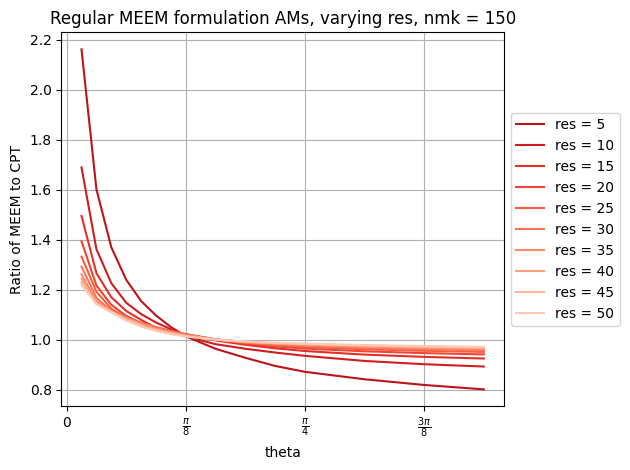

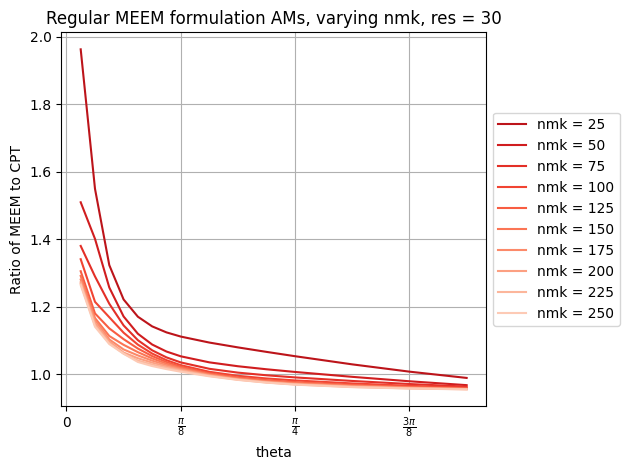

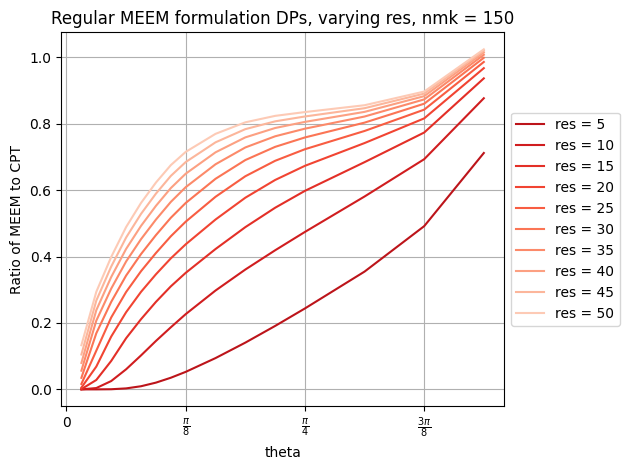

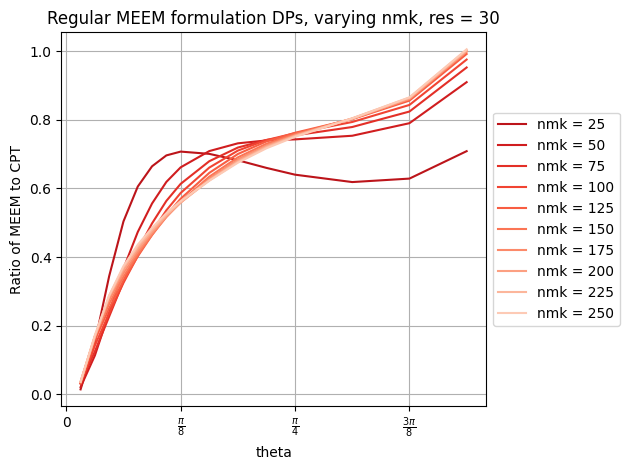

In [8]:
plot1(configurations, "AM", "res")
plot1(configurations, "AM", "nmk")
plot1(configurations, "DP", "res")
plot1(configurations, "DP", "nmk")

For modified MEEM, the hydro coefficient integral is approximated on the slant by taking the potential in the integral to be that at the body surface in the middle of each subdivision (halfway between the inner and outer radius of that subdivision). These results approximately show convergence to the correct Capytaine values as resolution and nmk increases. Notably, increasing nmk leads to some erratic behavior in added mass (uncertain if this is because nmk is not converged), but damping values seem to be much closer to the capytaine value than with the regular MEEM formulation.

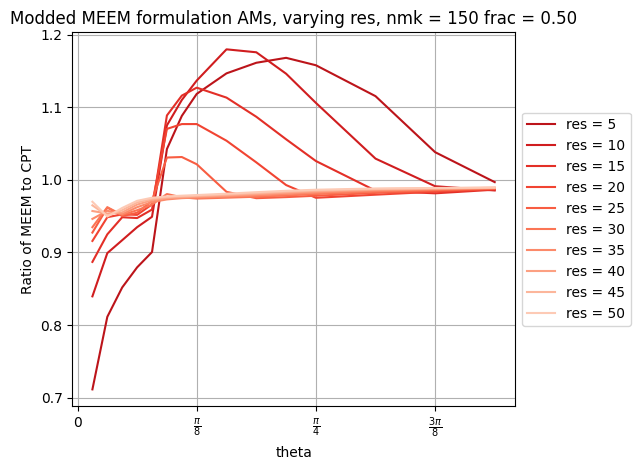

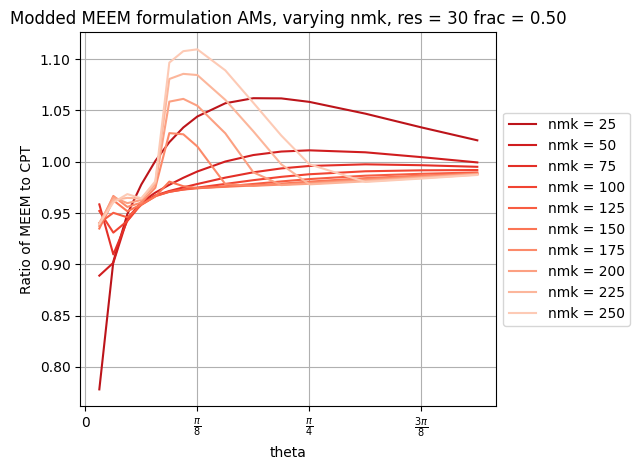

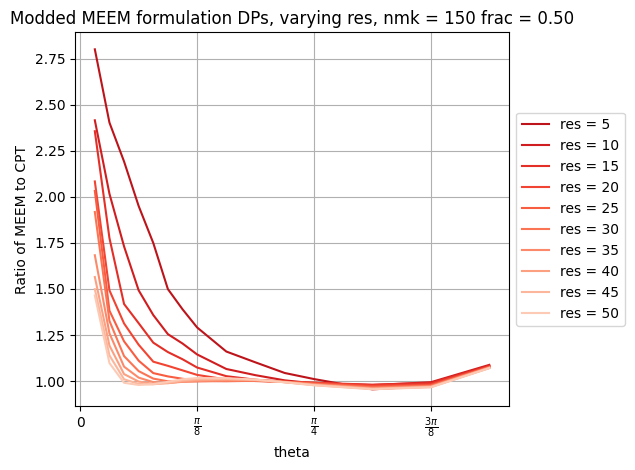

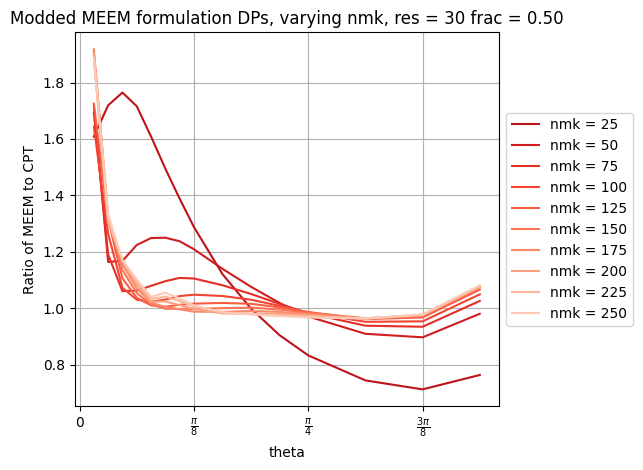

In [11]:
plot2(configurations, "AM", "res", 9)
plot2(configurations, "AM", "nmk", 9)
plot2(configurations, "DP", "res", 9)
plot2(configurations, "DP", "nmk", 9)

Question: Is there a best place to sample the potential for the hydro coefficient integral that's not the middle, perhaps dependent on slope/angle? Here, the computed hydro coefficient is plotted, with different lines showing different fractions of the way through the subdivisions where the potentials were sampled. Overall, there isn't a predictable dependence on slope, so halfway is a good idea.

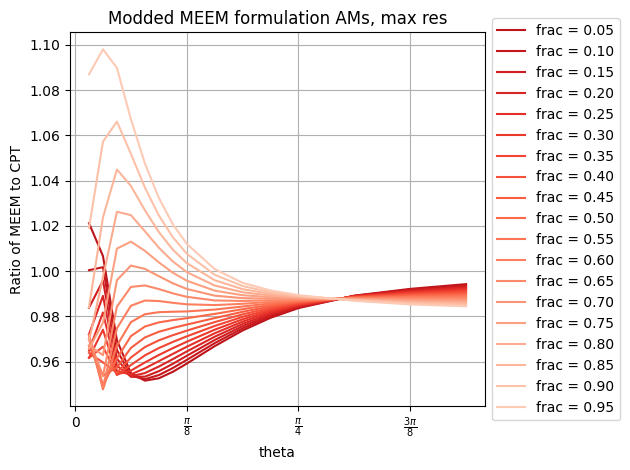

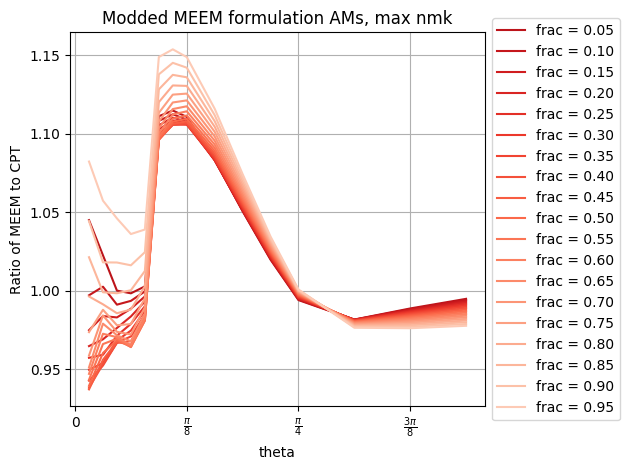

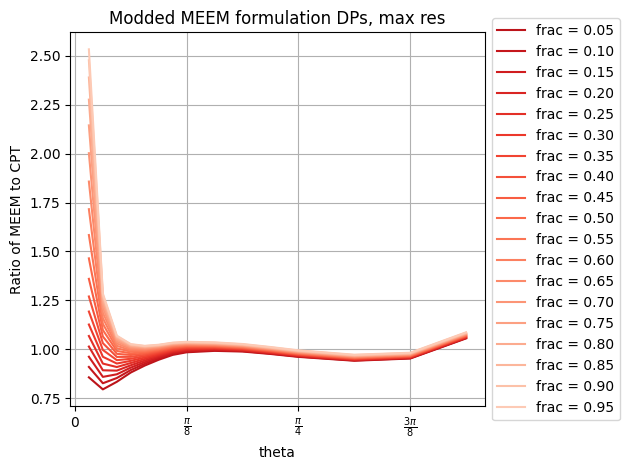

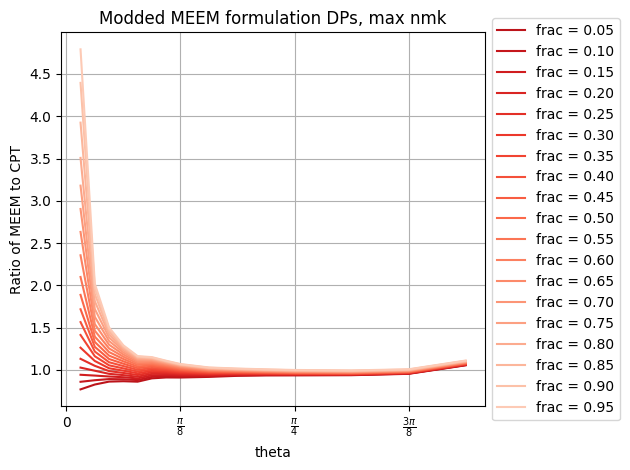

In [11]:
plot3(configurations, "AM", "res", -1)
plot3(configurations, "AM", "nmk", -1)
plot3(configurations, "DP", "res", -1)
plot3(configurations, "DP", "nmk", -1)

Now, for reference of desired accuracy, compare the MEEM and capytaine values for a non-slanted (box) configuration. These plots show that much less nmk is needed for the convergence in this case. Post convergence-study, this behavior makes sense, as the tall, narrow, subdivisions in slant-approximating MEEM needs more NMK to resolve.

An unanswered question is why there is so much agreement between MEEM and Capytaine here about damping (so Capytaine's damping value must be correct), while for slanted configurations, it seems possible that Capytaine is unconverged.

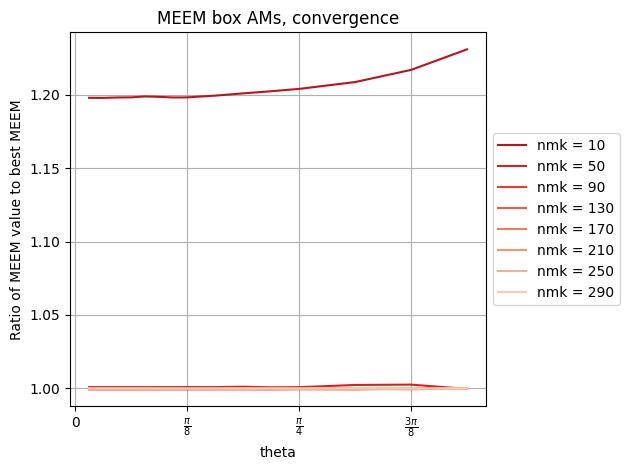

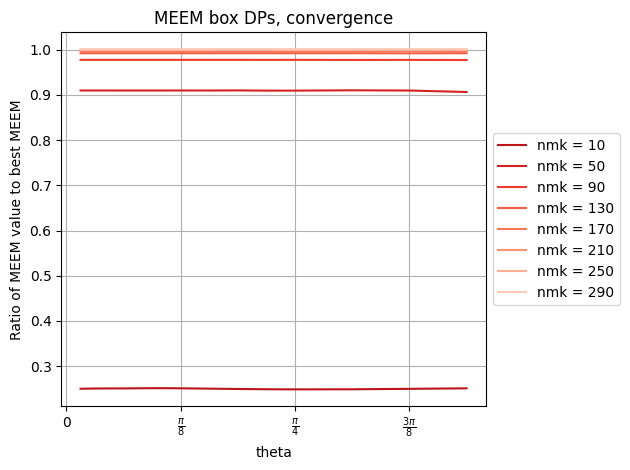

In [12]:
plot4(configurations, "AM")
plot4(configurations, "DP")

# Note: NMK convergence for these is a lot better than for the slants.
# (h-d)/radwidth reasons

For regular MEEM, while geometries with shallow slopes appear to converge, it is less clear that those with steep ones do. These plots convert resolution and slope into delta-d (the change in depth between adjacent subdivisions), showing a clearer picture of how increasing subdivisions (reducing delta-d) leads to convergence, even if the slope is steep, because the patterns are observable as the slope (angle) changes. This convergence across steepnesses is particularly visible in the shape of the damping curve. Modified MEEM is also plotted, and also implies eventual convergence, although it is much less monotonic/predictable.

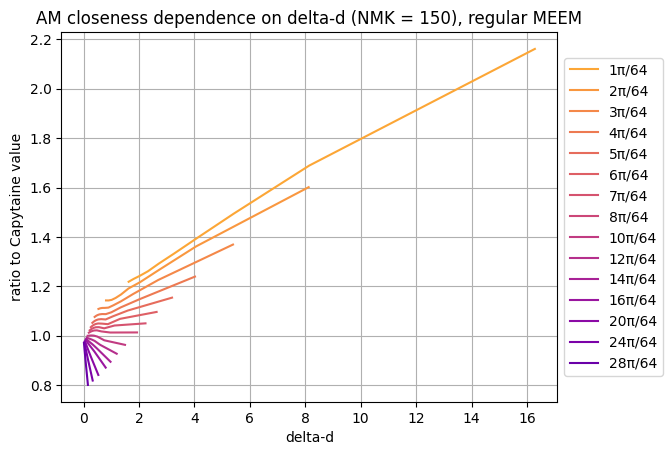

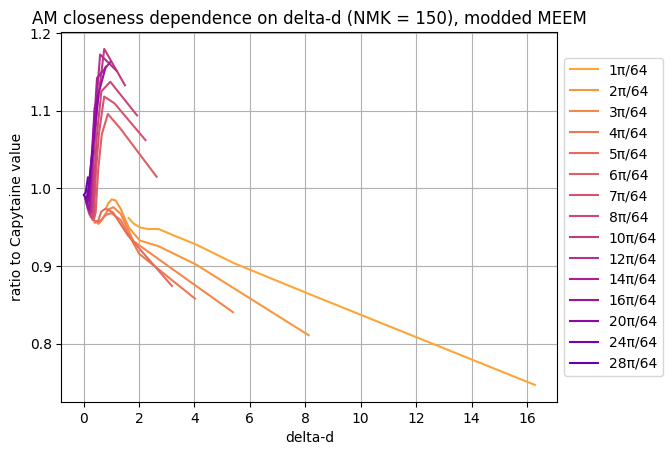

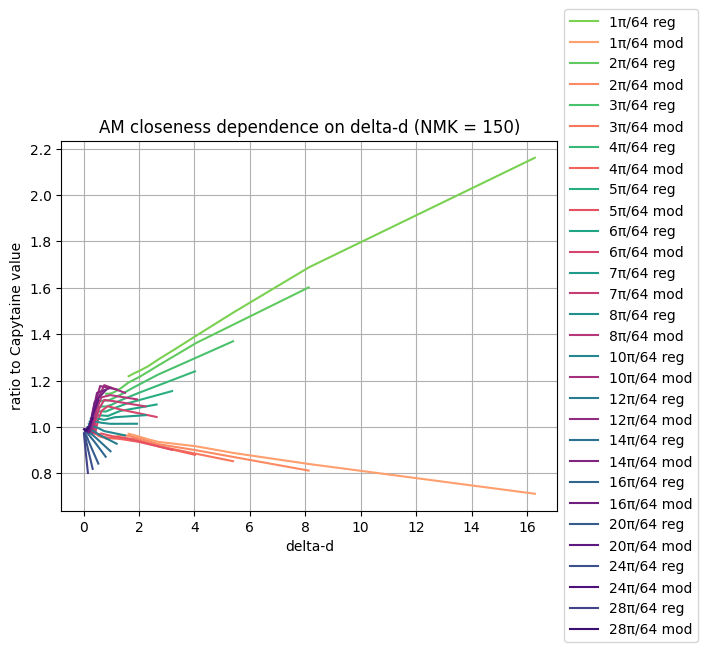

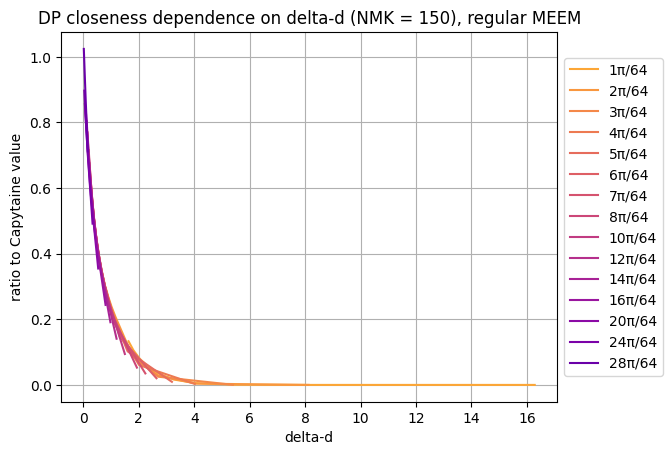

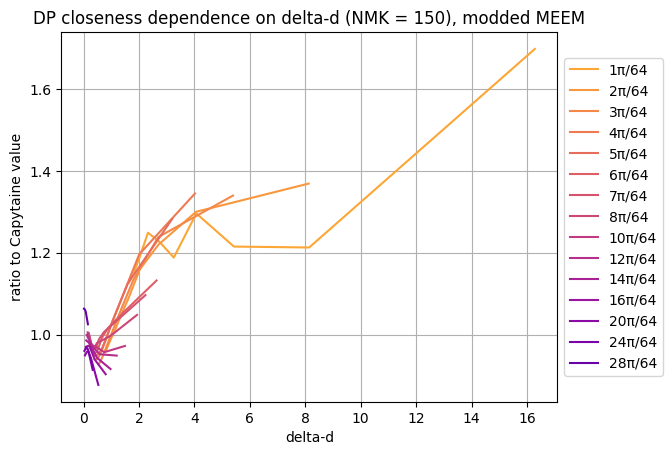

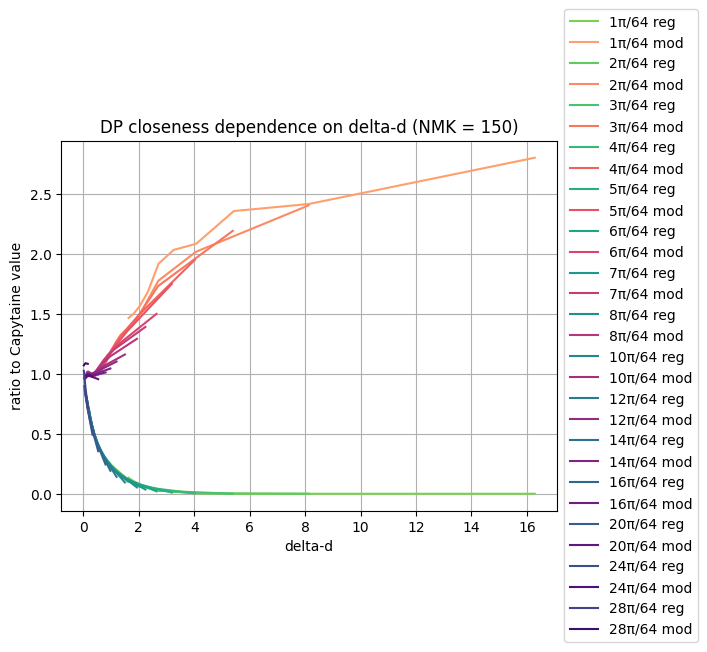

In [14]:
plot5(configurations, "AM", "regular")
plot5(configurations, "AM", "modded")
plot6(configurations, "AM")
plot5(configurations, "DP", "regular")
plot5(configurations, "DP", "modded")
plot6(configurations, "DP")